# SC2001 Project 1

## Integration of Merge Sort & Insertion Sort

### Experimental Data / Slide Source


## Algorithm Implementations

Hybrid threshold rule: switch to Insertion Sort when the current subarray size is less than or equal to `S`. Original Merge Sort uses the same merge and auxiliary-array logic with a one-element base case.

For reference, the hybrid average/worst-case structure is

$$T(n,S)=\Theta\left(n\log_2\frac{n}{S}+nS\right).$$

For power-of-two $n$, the exact worst-case Merge Sort comparison count is $n\log_2n-n+1$. These are reference expressions, not exact predictions for a particular random dataset.


In [1]:
from __future__ import annotations

import gc
import math
import platform
import random
import statistics
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

SEED = 2001
MAX_VALUE = 10_000_000
RESULTS_DIR = Path("results")
PLOTS_DIR = Path("plots")
RESULTS_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_rows", 100)
plt.style.use("seaborn-v0_8-whitegrid")

cpu_clock = time.get_clock_info("process_time")
print(f"Python {sys.version.split()[0]} on {platform.platform()}")
print(f"Random seed = {SEED:,}; generated values are in [1, {MAX_VALUE:,}]")
print(
    "CPU timer: time.process_time_ns(); "
    f"implementation={cpu_clock.implementation}; "
    f"reported resolution={cpu_clock.resolution:.9g} s; monotonic={cpu_clock.monotonic}"
)


Python 3.12.10 on Windows-11-10.0.26200-SP0
Random seed = 2,001; generated values are in [1, 10,000,000]
CPU timer: time.process_time_ns(); implementation=GetProcessTimes(); reported resolution=1e-07 s; monotonic=True


In [2]:
def insertion_sort_range(values: list[int], left: int, right: int) -> int:
    comparisons = 0
    for i in range(left + 1, right + 1):
        key = values[i]
        j = i - 1
        while j >= left:
            comparisons += 1
            if values[j] <= key:
                break
            values[j + 1] = values[j]
            j -= 1
        values[j + 1] = key
    return comparisons


def merge(values: list[int], auxiliary: list[int], left: int, mid: int, right: int) -> int:
    for position in range(left, right + 1):
        auxiliary[position] = values[position]

    i, j = left, mid + 1
    comparisons = 0

    for destination in range(left, right + 1):
        if i > mid:
            values[destination] = auxiliary[j]
            j += 1
        elif j > right:
            values[destination] = auxiliary[i]
            i += 1
        else:
            comparisons += 1
            if auxiliary[i] <= auxiliary[j]:
                values[destination] = auxiliary[i]
                i += 1
            else:
                values[destination] = auxiliary[j]
                j += 1
    return comparisons


def merge_sort(values: list[int]) -> int:
    auxiliary = [0] * len(values)

    def sort(left: int, right: int) -> int:
        if left >= right:
            return 0
        mid = (left + right) // 2
        comparisons = sort(left, mid)
        comparisons += sort(mid + 1, right)
        comparisons += merge(values, auxiliary, left, mid, right)
        return comparisons

    return sort(0, len(values) - 1)


def hybrid_merge_sort(values: list[int], threshold: int) -> int:
    if threshold < 1:
        raise ValueError("threshold must be at least 1")
    auxiliary = [0] * len(values)

    def sort(left: int, right: int) -> int:
        size = right - left + 1
        if size <= threshold:
            return insertion_sort_range(values, left, right)
        mid = (left + right) // 2
        comparisons = sort(left, mid)
        comparisons += sort(mid + 1, right)
        comparisons += merge(values, auxiliary, left, mid, right)
        return comparisons

    return 0 if not values else sort(0, len(values) - 1)


In [3]:
def make_dataset(n: int, seed: int) -> list[int]:
    rng = random.Random(seed)
    return [rng.randint(1, MAX_VALUE) for _ in range(n)]


def measure_prepared_sort(algorithm, working: list[int], *args) -> tuple[int, float]:
    """Time only the sorting call; working must already be an independent copy."""
    start_ns = time.process_time_ns()
    comparisons = algorithm(working, *args)
    cpu_seconds = (time.process_time_ns() - start_ns) / 1_000_000_000
    return comparisons, cpu_seconds


def run_sort_once(algorithm, source: list[int], *args) -> tuple[int, float]:
    working = source.copy()  # Restore input outside the timed region.
    comparisons, cpu_seconds = measure_prepared_sort(algorithm, working, *args)
    assert is_sorted(working)  # Validate outside the timed region.
    del working
    return comparisons, cpu_seconds


## Correctness Validation


In [4]:
def is_sorted(values: list[int]) -> bool:
    return all(values[i - 1] <= values[i] for i in range(1, len(values)))


test_cases = [
    [], [7], [2, 1], [3, 1, 2], [4, 1, 4, 2, 0],
    list(range(20)), list(range(19, -1, -1)),
]

for case in test_cases:
    expected = sorted(case)  # Used only as a test oracle, never by the algorithms.
    ordinary = case.copy()
    merge_sort(ordinary)
    assert ordinary == expected
    for threshold in (1, 2, 4, 8, 32):
        hybrid = case.copy()
        hybrid_merge_sort(hybrid, threshold)
        assert hybrid == expected

# With S = 1, the hybrid follows exactly the same recursion and merge operations.
rng = random.Random(SEED)
sample = [rng.randint(1, 100) for _ in range(1_001)]
a, b = sample.copy(), sample.copy()
ordinary_count = merge_sort(a)
hybrid_count = hybrid_merge_sort(b, 1)
assert a == b and ordinary_count == hybrid_count

print("Correctness checks passed, including structural equivalence at S = 1.")


Correctness checks passed, including structural equivalence at S = 1.


## (c)(i) Fixed S, Vary n

Fixed threshold: `S = 16`. The table contains the full recorded comparison counts, comparisons per element, and comparisons divided by $n\log_2n$. The dashed plot series is the reference value $n\log_2n$. In the right-hand chart, a flatter ratio near 1 means the observed comparison count grows proportionally to $n\log_2n$.


Table C1: Key comparisons with fixed S = 16


,n,S,comparisons,comparisons_per_n,comparisons_per_n_log2_n
0,1000,16,10413,10.413000,1.044875
1,2000,16,22598,11.299000,1.030387
2,5000,16,58584,11.716800,0.953538
3,10000,16,127112,12.711200,0.956613
4,20000,16,274483,13.724150,0.960556
5,50000,16,770552,15.411040,0.987277
6,100000,16,1638368,16.383680,0.986396
7,200000,16,3478148,17.390740,0.987569
8,500000,16,9609207,19.218414,1.015152
9,1000000,16,20223321,20.223321,1.014638


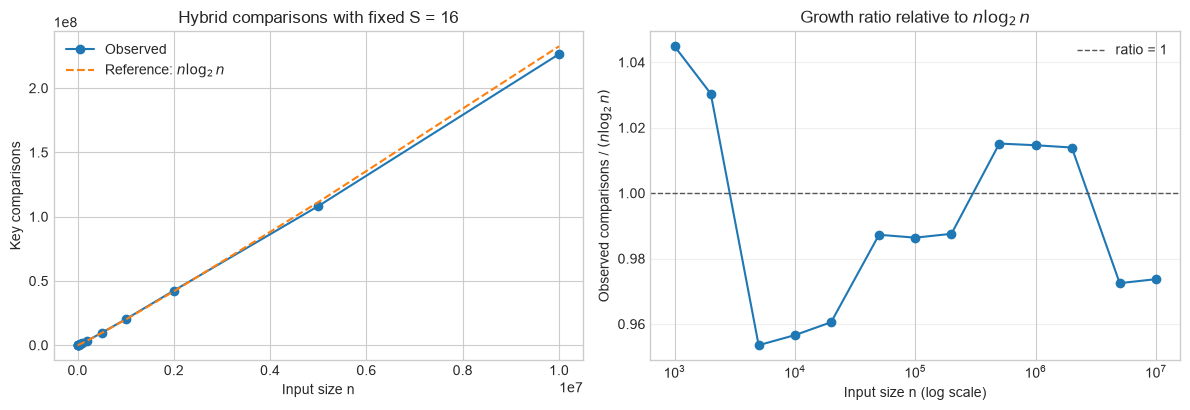

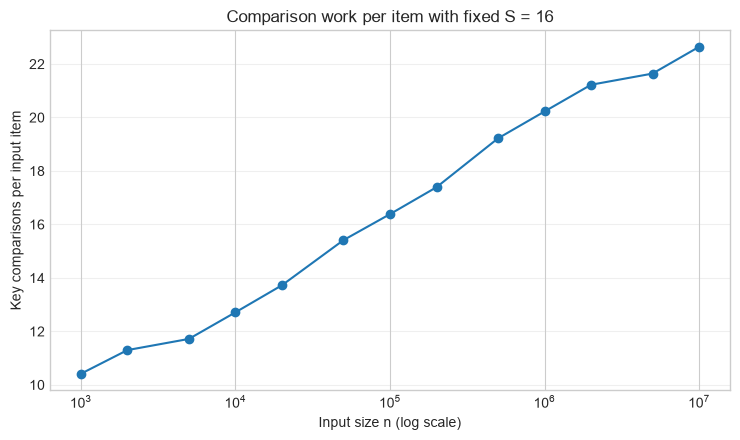

In [5]:
FIXED_S = 16
SIZES_C1 = [
    1_000, 2_000, 5_000, 10_000, 20_000, 50_000, 100_000,
    200_000, 500_000, 1_000_000, 2_000_000, 5_000_000, 10_000_000,
]

c1_rows = []
for n in SIZES_C1:
    data = make_dataset(n, SEED + n)
    comparisons, _ = run_sort_once(hybrid_merge_sort, data, FIXED_S)
    c1_rows.append({
        "n": n,
        "S": FIXED_S,
        "comparisons": comparisons,
        "comparisons_per_n": comparisons / n,
        "comparisons_per_n_log2_n": comparisons / (n * math.log2(n)),
    })
    del data
    gc.collect()

c1 = pd.DataFrame(c1_rows)
c1.to_csv(RESULTS_DIR / "c1_fixed_s_varying_n.csv", index=False)
print(f"Table C1: Key comparisons with fixed S = {FIXED_S}")
display(c1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(c1["n"], c1["comparisons"], marker="o", label="Observed")
axes[0].plot(c1["n"], c1["n"] * c1["n"].map(math.log2), linestyle="--", label=r"Reference: $n\log_2n$")
axes[0].set(xlabel="Input size n", ylabel="Key comparisons", title=f"Hybrid comparisons with fixed S = {FIXED_S}")
axes[0].ticklabel_format(style="sci", axis="both", scilimits=(0, 0))
axes[0].legend()

axes[1].plot(c1["n"], c1["comparisons_per_n_log2_n"], marker="o")
axes[1].axhline(1.0, color="#555555", linestyle="--", linewidth=1, label=r"ratio = 1")
axes[1].set_xscale("log")
axes[1].set(xlabel="Input size n (log scale)", ylabel=r"Observed comparisons / $(n\log_2 n)$", title=r"Growth ratio relative to $n\log_2 n$")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / "c1_comparisons_vs_n.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(c1["n"], c1["comparisons_per_n"], marker="o")
ax.set_xscale("log")
ax.set_xlabel("Input size n (log scale)")
ax.set_ylabel("Key comparisons per input item")
ax.set_title(f"Comparison work per item with fixed S = {FIXED_S}")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "c1_comparisons_per_element.png", dpi=180, bbox_inches="tight")
plt.show()



## (c)(ii) Fixed n, Vary S

Fixed input size: `n = 200,000`. The same unsorted dataset is used for every threshold.


Table C2: Key comparisons across S for fixed n = 200,000


,n,S,comparisons
0,200000,2,3272851
1,200000,4,3273283
2,200000,8,3315694
3,200000,16,3478396
4,200000,32,3922280
5,200000,64,4962322


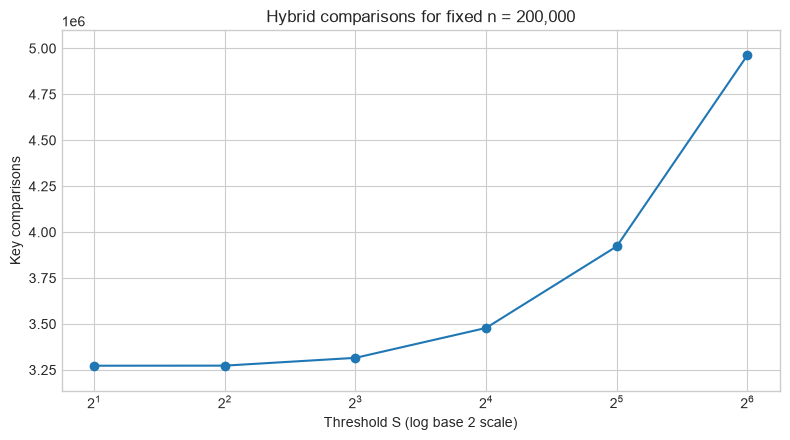

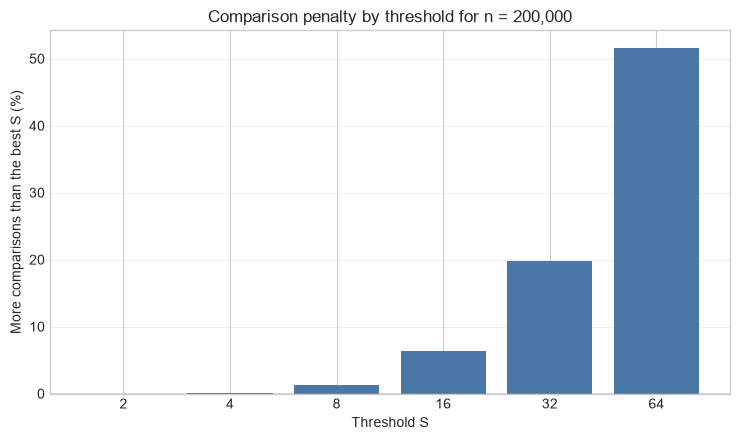

Fewest key comparisons in this experiment: S = 2 at 3,272,851 comparisons.


7184

In [11]:
FIXED_N = 200_000
S_VALUES = [2, 4, 8, 16, 32, 64]
fixed_data = make_dataset(FIXED_N, SEED + 20_000_000)

c2_rows = []
for threshold in S_VALUES:
    comparisons, _ = run_sort_once(hybrid_merge_sort, fixed_data, threshold)
    c2_rows.append({"n": FIXED_N, "S": threshold, "comparisons": comparisons})

c2 = pd.DataFrame(c2_rows)
c2.to_csv(RESULTS_DIR / "c2_fixed_n_varying_s.csv", index=False)
print(f"Table C2: Key comparisons across S for fixed n = {FIXED_N:,}")
display(c2)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(c2["S"], c2["comparisons"], marker="o")
ax.set_xscale("log", base=2)
ax.set_xlabel("Threshold S (log base 2 scale)")
ax.set_ylabel("Key comparisons")
ax.set_title(f"Hybrid comparisons for fixed n = {FIXED_N:,}")
comparison_span = c2["comparisons"].max() - c2["comparisons"].min()
comparison_padding = max(comparison_span * 0.08, c2["comparisons"].max() * 0.005)
ax.set_ylim(c2["comparisons"].min() - comparison_padding, c2["comparisons"].max() + comparison_padding)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "c2_comparisons_vs_s.png", dpi=180, bbox_inches="tight")
plt.show()

minimum_comparisons_c2 = c2["comparisons"].min()
comparison_penalty_percent = 100 * (c2["comparisons"] / minimum_comparisons_c2 - 1)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(c2["S"].astype(str), comparison_penalty_percent, color="#4C78A8")
ax.set_xlabel("Threshold S")
ax.set_ylabel("More comparisons than the best S (%)")
ax.set_title(f"Comparison penalty by threshold for n = {FIXED_N:,}")
ax.axhline(0, color="#555555", linewidth=1)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "c2_comparison_penalty_by_s.png", dpi=180, bbox_inches="tight")
plt.show()

comparison_best_s_c2 = c2.loc[c2["comparisons"] == minimum_comparisons_c2, "S"].tolist()
print(f"Fewest key comparisons in this experiment: S = 2 at {minimum_comparisons_c2:,} comparisons.")
del fixed_data
gc.collect()


## (c)(iii) CPU-Time Sweep Across S

Five CPU-time measurements are recorded for every tested `(n, S)` pair. The full table contains all five runs, their median, exact comparison counts, and the median divided by the minimum median for that input size. Per-size measured minima use the first `S` at which a tied minimum occurs.

The aggregate threshold table records mean relative median CPU time and mean comparisons. The selected threshold is the one with the lowest measured aggregate median CPU time; if that value is exactly tied, the first tested `S` is used.


Table C3: Raw CPU-time measurements and exact comparison counts


,n,S,comparisons,cpu_run_1,cpu_run_2,cpu_run_3,cpu_run_4,cpu_run_5,median_cpu_time,relative_median_cpu_time,cpu_time_over_fastest_percent
0,100000,2,1536133,0.140625,0.140625,0.140625,0.140625,0.140625,0.140625,1.285714,28.571429
1,100000,4,1536761,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,1.142857,14.285714
2,100000,8,1557387,0.109375,0.125000,0.125000,0.125000,0.125000,0.125000,1.142857,14.285714
3,100000,12,1619056,0.125000,0.109375,0.109375,0.125000,0.125000,0.125000,1.142857,14.285714
4,100000,16,1639048,0.109375,0.109375,0.109375,0.109375,0.125000,0.109375,1.000000,0.000000
5,100000,20,1639048,0.125000,0.125000,0.125000,0.125000,0.109375,0.125000,1.142857,14.285714
6,100000,24,1765444,0.109375,0.125000,0.109375,0.125000,0.109375,0.109375,1.000000,0.000000
7,100000,32,1862273,0.109375,0.125000,0.125000,0.109375,0.125000,0.125000,1.142857,14.285714
8,100000,48,1950925,0.109375,0.125000,0.125000,0.125000,0.125000,0.125000,1.142857,14.285714
9,100000,64,2386479,0.140625,0.140625,0.156250,0.140625,0.140625,0.140625,1.285714,28.571429


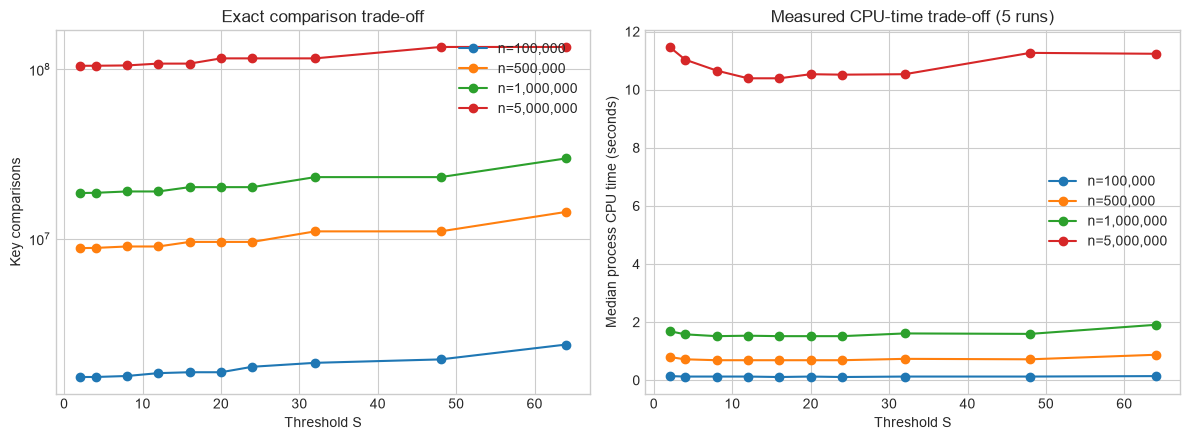

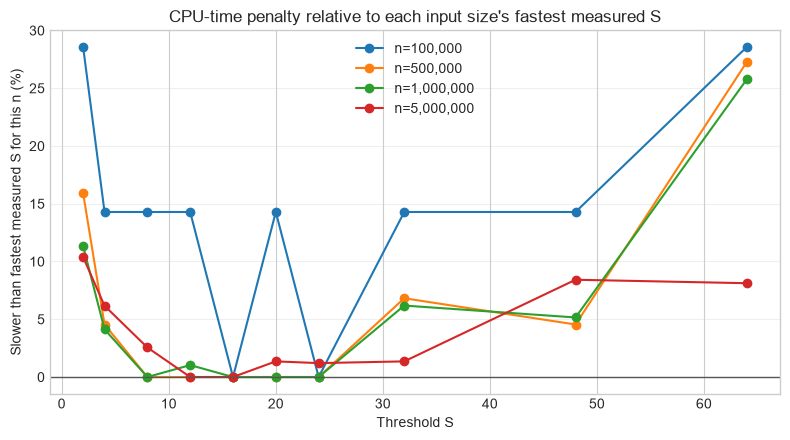

Table C4: CPU-time penalty by S (0% is the fastest measured time for that n)


,"n=100,000","n=500,000","n=1,000,000","n=5,000,000"
S,,,,
2,28.6%,15.9%,11.3%,10.4%
4,14.3%,4.5%,4.1%,6.2%
8,14.3%,0.0%,0.0%,2.6%
12,14.3%,0.0%,1.0%,0.0%
16,0.0%,0.0%,0.0%,0.0%
20,14.3%,0.0%,0.0%,1.4%
24,0.0%,0.0%,0.0%,1.2%
32,14.3%,6.8%,6.2%,1.4%
48,14.3%,4.5%,5.2%,8.4%


Table C5: S with the fewest exact comparisons for each input size


,n,comparison_best_S,comparisons
0,100000,2,1536133
10,500000,2,8837346
20,1000000,2,18675172
30,5000000,2,105050548


Table C6: S with the fastest measured median CPU time for each input size


,n,time_best_S,median_cpu_time
4,100000,16,0.109375
12,500000,8,0.687500
22,1000000,8,1.515625
33,5000000,12,10.390625


Table C7: Aggregate threshold summary used to select S


,S,mean_relative_median_cpu_time,mean_comparisons
0,2,1.165492,33524799.75
1,4,1.072801,33560557.00
2,8,1.042105,33804701.25
3,12,1.038292,34483601.25
4,16,1.000000,34921343.75
5,20,1.039098,36913135.00
6,24,1.003008,36944734.00
7,32,1.071607,38076334.75
8,48,1.081017,42962654.00
9,64,1.224344,45583931.00


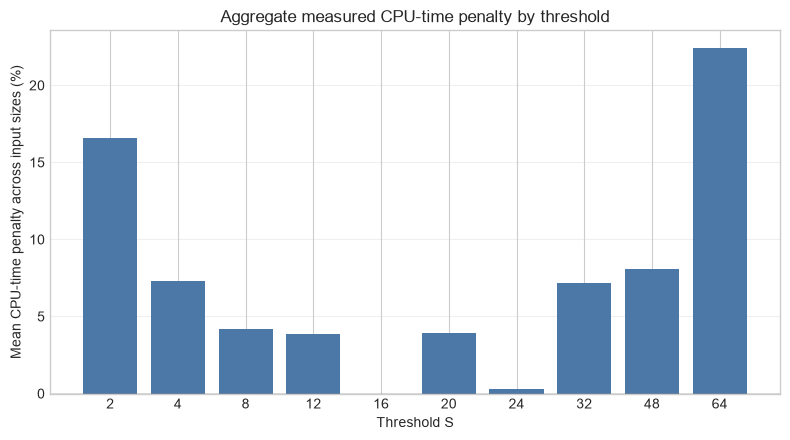

In [9]:
SIZES_C3 = [100_000, 500_000, 1_000_000, 5_000_000]
S_VALUES_C3 = [2, 4, 8, 12, 16, 20, 24, 32, 48, 64]
CPU_REPETITIONS = 5

c3_rows = []
for n in SIZES_C3:
    data = make_dataset(n, SEED + 30_000_000 + n)
    timings = {threshold: [] for threshold in S_VALUES_C3}
    counts = {}

    for repetition in range(CPU_REPETITIONS):
        threshold_order = S_VALUES_C3 if repetition % 2 == 0 else list(reversed(S_VALUES_C3))
        for threshold in threshold_order:
            working = data.copy()  # Outside timed region.
            comparisons, cpu_seconds = measure_prepared_sort(hybrid_merge_sort, working, threshold)
            assert is_sorted(working)
            del working

            if threshold in counts:
                assert comparisons == counts[threshold], "Comparison count changed for identical data and S"
            else:
                counts[threshold] = comparisons
            timings[threshold].append(cpu_seconds)

    for threshold in S_VALUES_C3:
        row = {"n": n, "S": threshold, "comparisons": counts[threshold]}
        row.update({f"cpu_run_{i + 1}": value for i, value in enumerate(timings[threshold])})
        row["median_cpu_time"] = statistics.median(timings[threshold])
        c3_rows.append(row)

    del data
    gc.collect()

c3 = pd.DataFrame(c3_rows)
c3["relative_median_cpu_time"] = c3.groupby("n")["median_cpu_time"].transform(lambda x: x / x.min())
c3["cpu_time_over_fastest_percent"] = 100 * (c3["relative_median_cpu_time"] - 1)
c3.to_csv(RESULTS_DIR / "c3_optimal_s_raw.csv", index=False)
print("Table C3: Raw CPU-time measurements and exact comparison counts")
display(c3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for n, group in c3.groupby("n"):
    axes[0].plot(group["S"], group["comparisons"], marker="o", label=f"n={n:,}")
    axes[1].plot(group["S"], group["median_cpu_time"], marker="o", label=f"n={n:,}")
for ax in axes:
    ax.set_xlabel("Threshold S")
    ax.legend()
axes[0].set_ylabel("Key comparisons")
axes[0].set_title("Exact comparison trade-off")
axes[1].set_ylabel("Median process CPU time (seconds)")
axes[1].set_title("Measured CPU-time trade-off (5 runs)")
axes[0].set_yscale("log")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "c3_threshold_tradeoff.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
for n, group in c3.groupby("n"):
    ax.plot(group["S"], group["cpu_time_over_fastest_percent"], marker="o", label=f"n={n:,}")
ax.axhline(0, color="#555555", linewidth=1)
ax.set_xlabel("Threshold S")
ax.set_ylabel("Slower than fastest measured S for this n (%)")
ax.set_title("CPU-time penalty relative to each input size's fastest measured S")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "c3_cpu_time_penalty_by_s.png", dpi=180, bbox_inches="tight")
plt.show()

time_penalty_table = c3.pivot(index="S", columns="n", values="cpu_time_over_fastest_percent")
time_penalty_table.columns = [f"n={n:,}" for n in time_penalty_table.columns]
print("Table C4: CPU-time penalty by S (0% is the fastest measured time for that n)")
display(time_penalty_table.style.format("{:.1f}%").highlight_min(axis=0, color="#d9ead3"))

comparison_best_by_n = c3.loc[c3.groupby("n")["comparisons"].idxmin(), ["n", "S", "comparisons"]]
time_best_by_n = c3.loc[c3.groupby("n")["median_cpu_time"].idxmin(), ["n", "S", "median_cpu_time"]]
print("Table C5: S with the fewest exact comparisons for each input size")
display(comparison_best_by_n.rename(columns={"S": "comparison_best_S"}))
print("Table C6: S with the fastest measured median CPU time for each input size")
display(time_best_by_n.rename(columns={"S": "time_best_S"}))

threshold_summary = c3.groupby("S", as_index=False).agg(
    mean_relative_median_cpu_time=("relative_median_cpu_time", "mean"),
    mean_comparisons=("comparisons", "mean"),
)
selected_s = int(threshold_summary.loc[threshold_summary["mean_relative_median_cpu_time"].idxmin(), "S"])
threshold_summary.to_csv(RESULTS_DIR / "c3_threshold_summary.csv", index=False)
print("Table C7: Aggregate threshold summary used to select S")
display(threshold_summary)

mean_cpu_time_penalty_percent = 100 * (threshold_summary["mean_relative_median_cpu_time"] - 1)
bar_colors = ["#F58518" if threshold == selected_s else "#4C78A8" for threshold in threshold_summary["S"]]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(threshold_summary["S"].astype(str), mean_cpu_time_penalty_percent, color=bar_colors)
ax.set_xlabel("Threshold S")
ax.set_ylabel("Mean CPU-time penalty across input sizes (%)")
ax.set_title("Aggregate measured CPU-time penalty by threshold")
ax.axhline(0, color="#555555", linewidth=1)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "c3_mean_cpu_time_penalty_by_s.png", dpi=180, bbox_inches="tight")
plt.show()



## (d) Original Merge Sort vs Hybrid

Input size: `n = 10,000,000`. Representative Hybrid threshold: `S = 16`. Each algorithm sorts three copies of the same dataset in the counterbalanced order shown in the experimental configuration.


Table D1: Raw counterbalanced 10,000,000-item timing runs


,sequence_position,algorithm,algorithm_run,n,S,comparisons,cpu_time
0,1,Original Merge Sort,1,10000000,NaN,220098332,28.546875
1,2,Hybrid Merge/Insertion Sort,1,10000000,16.0,226415036,25.609375
2,3,Hybrid Merge/Insertion Sort,2,10000000,16.0,226415036,25.656250
3,4,Original Merge Sort,2,10000000,NaN,220098332,30.593750
4,5,Original Merge Sort,3,10000000,NaN,220098332,30.156250
5,6,Hybrid Merge/Insertion Sort,3,10000000,16.0,226415036,25.609375


Table D2: 10,000,000-item median CPU-time comparison


,algorithm,n,S,comparisons,cpu_run_1,cpu_run_2,cpu_run_3,median_cpu_time,absolute_comparison_difference_hybrid_minus_merge,percentage_comparison_difference,absolute_median_cpu_difference_hybrid_minus_merge,percentage_median_cpu_difference,merge_over_hybrid_speedup_ratio
0,Hybrid Merge/Insertion Sort,10000000,16.0,226415036,25.609375,25.65625,25.609375,25.609375,6316704,2.869946,-4.546875,-15.07772,1.177547
1,Original Merge Sort,10000000,NaN,220098332,28.546875,30.59375,30.156250,30.156250,6316704,2.869946,-4.546875,-15.07772,1.177547


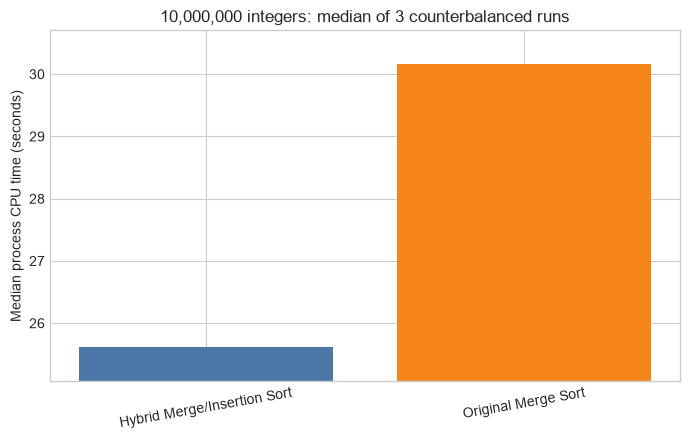

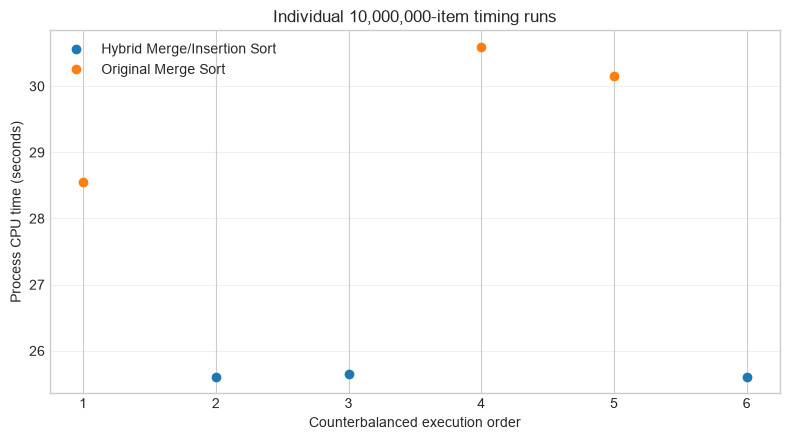

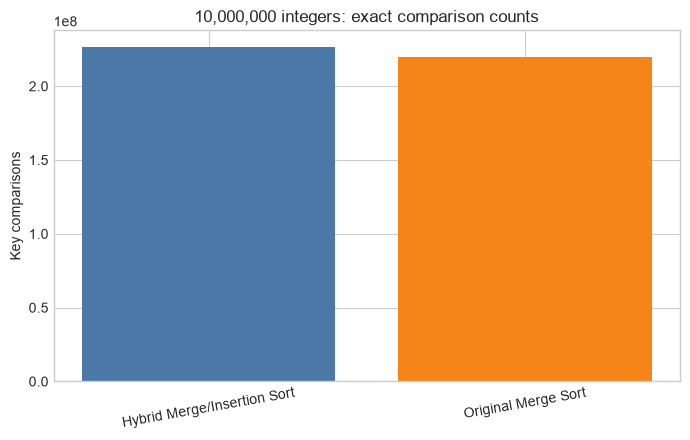

Selected S: 16
Absolute comparison difference (Hybrid - Merge): +6,316,704
Percentage comparison difference: +2.870%
Absolute median CPU-time difference (Hybrid - Merge): -4.546875 s
Percentage median CPU-time difference: -15.078%
Speedup ratio (Merge median / Hybrid median): 1.178x


5836

In [10]:
N_FINAL = 10_000_000
FINAL_RUN_ORDER = ["Merge", "Hybrid", "Hybrid", "Merge", "Merge", "Hybrid"]
final_data = make_dataset(N_FINAL, SEED + 40_000_000)

d_rows = []
expected_counts = {}
algorithm_run_numbers = {"Merge": 0, "Hybrid": 0}

for sequence_position, label in enumerate(FINAL_RUN_ORDER, start=1):
    algorithm_run_numbers[label] += 1
    working = final_data.copy()  # Restore identical input outside the timed interval.
    if label == "Merge":
        comparisons, cpu_seconds = measure_prepared_sort(merge_sort, working)
        threshold = None
        algorithm_name = "Original Merge Sort"
    else:
        comparisons, cpu_seconds = measure_prepared_sort(hybrid_merge_sort, working, selected_s)
        threshold = selected_s
        algorithm_name = "Hybrid Merge/Insertion Sort"

    assert is_sorted(working)
    del working
    gc.collect()

    if label in expected_counts:
        assert comparisons == expected_counts[label], "Comparison count changed across identical runs"
    else:
        expected_counts[label] = comparisons

    d_rows.append({
        "sequence_position": sequence_position,
        "algorithm": algorithm_name,
        "algorithm_run": algorithm_run_numbers[label],
        "n": N_FINAL,
        "S": threshold,
        "comparisons": comparisons,
        "cpu_time": cpu_seconds,
    })

d_raw = pd.DataFrame(d_rows)
d_raw.to_csv(RESULTS_DIR / "d_10m_raw_runs.csv", index=False)
print("Table D1: Raw counterbalanced 10,000,000-item timing runs")
display(d_raw)

d_summary = d_raw.groupby("algorithm", as_index=False).agg(
    n=("n", "first"),
    S=("S", "first"),
    comparisons=("comparisons", "first"),
    cpu_run_1=("cpu_time", lambda x: list(x)[0]),
    cpu_run_2=("cpu_time", lambda x: list(x)[1]),
    cpu_run_3=("cpu_time", lambda x: list(x)[2]),
    median_cpu_time=("cpu_time", "median"),
)

merge_summary = d_summary.loc[d_summary["algorithm"] == "Original Merge Sort"].iloc[0]
hybrid_summary = d_summary.loc[d_summary["algorithm"] == "Hybrid Merge/Insertion Sort"].iloc[0]

absolute_comparison_difference = int(hybrid_summary["comparisons"] - merge_summary["comparisons"])
percentage_comparison_difference = 100 * absolute_comparison_difference / merge_summary["comparisons"]
absolute_cpu_difference = hybrid_summary["median_cpu_time"] - merge_summary["median_cpu_time"]
percentage_cpu_difference = 100 * absolute_cpu_difference / merge_summary["median_cpu_time"]
speedup_ratio = merge_summary["median_cpu_time"] / hybrid_summary["median_cpu_time"]

d_summary["absolute_comparison_difference_hybrid_minus_merge"] = absolute_comparison_difference
d_summary["percentage_comparison_difference"] = percentage_comparison_difference
d_summary["absolute_median_cpu_difference_hybrid_minus_merge"] = absolute_cpu_difference
d_summary["percentage_median_cpu_difference"] = percentage_cpu_difference
d_summary["merge_over_hybrid_speedup_ratio"] = speedup_ratio
d_summary.to_csv(RESULTS_DIR / "d_10m_summary.csv", index=False)
print("Table D2: 10,000,000-item median CPU-time comparison")
display(d_summary)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(d_summary["algorithm"], d_summary["median_cpu_time"], color=["#4C78A8", "#F58518"])
ax.set_ylabel("Median process CPU time (seconds)")
ax.set_title("10,000,000 integers: median of 3 counterbalanced runs")
ax.tick_params(axis="x", rotation=10)
timing_span = d_summary["median_cpu_time"].max() - d_summary["median_cpu_time"].min()
timing_padding = max(timing_span * 0.12, d_summary["median_cpu_time"].max() * 0.005)
ax.set_ylim(d_summary["median_cpu_time"].min() - timing_padding, d_summary["median_cpu_time"].max() + timing_padding)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "d_10m_median_cpu_time.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
for algorithm, group in d_raw.groupby("algorithm"):
    ax.plot(group["sequence_position"], group["cpu_time"], marker="o", linestyle="none", label=algorithm)
ax.set_xlabel("Counterbalanced execution order")
ax.set_ylabel("Process CPU time (seconds)")
ax.set_title("Individual 10,000,000-item timing runs")
ax.set_xticks(d_raw["sequence_position"])
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "d_10m_raw_cpu_time_by_sequence.png", dpi=180, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(d_summary["algorithm"], d_summary["comparisons"], color=["#4C78A8", "#F58518"])
ax.set_ylabel("Key comparisons")
ax.set_title("10,000,000 integers: exact comparison counts")
ax.tick_params(axis="x", rotation=10)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "d_10m_comparisons.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"Selected S: {selected_s}")
print(f"Absolute comparison difference (Hybrid - Merge): {absolute_comparison_difference:+,}")
print(f"Percentage comparison difference: {percentage_comparison_difference:+.3f}%")
print(f"Absolute median CPU-time difference (Hybrid - Merge): {absolute_cpu_difference:+.6f} s")
print(f"Percentage median CPU-time difference: {percentage_cpu_difference:+.3f}%")
print(f"Speedup ratio (Merge median / Hybrid median): {speedup_ratio:.3f}x")

del final_data
gc.collect()
